## SYNTHETIC DATA - CASE 1 
### Code to plot the model fit, forecast, joint pdfs of parameters and compute the bias and variance in model fit

In [1]:

import numpy as np
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import scipy.stats as st

dt = 0.1
tstart = 0
tlim = 200
t = np.arange(tstart, tlim, 1)

d_cut = 160

ndiv = 1/dt

### keep it always starting at 0
tmoh = np.arange(0, tlim, dt)

N_city = 1

PHU_path = '../../PHU_Data/'
figpath = '../../figs/predictions/test'
datapath = '../../data'

Data = np.zeros([365,4])

files = os.listdir(PHU_path)

target_file1 = f'{PHU_path}/30-Toronto.csv'
target_file2 = f'{PHU_path}/34-York.csv'
target_file3 = f'{PHU_path}/04-Durham.csv'
target_file4 = f'{PHU_path}/22-PeelRegion.csv'


Data[:,0] = np.genfromtxt(target_file1, delimiter=',')
Data[:,1] = np.genfromtxt(target_file2, delimiter=',')
Data[:,2] = np.genfromtxt(target_file3, delimiter=',')
Data[:,3] = np.genfromtxt(target_file4, delimiter=',')


population_by_phu = np.genfromtxt(f'{PHU_path}/population_by_phu.csv', delimiter=',')



#### CHANGE HERE ########

target_file5 = f'{datapath}/toronto_synthetic_data_noise10.csv'     # Synthetic data file path for Case 1
x_data = np.genfromtxt(target_file5, delimiter=',')

# x_data = Data[:,0] ## Real data for Toronto
t_data = np.arange(0,tlim)


# Preallocate compartments
S = np.zeros((len(tmoh),N_city))
E = np.zeros((len(tmoh),N_city))
I = np.zeros((len(tmoh),N_city))
R = np.zeros((len(tmoh),N_city))
D = np.zeros((len(tmoh),N_city))
N = np.zeros((len(tmoh),N_city))


# For noisy synthetic model output
I_model = np.zeros((len(t),N_city))
I_synthetic = np.zeros((len(t),N_city))

 
total = np.zeros((N_city))

 ####### CHANGE HERE FOR DIFFERENT PHU ######################
total[0] = population_by_phu[29,1]
 #####################################

# Model parameters - Taken from Southern Ontario - COVID MBE paper
gamma_e = 1/15
gamma_i = 1/5
gamma_r = 1/11
gamma_d = 1/750

beta_e = np.zeros((len(tmoh),N_city)) 
beta_i = np.zeros((len(tmoh),N_city))

beta_calibrated = np.zeros((len(tmoh),N_city))

print("total population in PHU1",total[0])

#### PEEL - 234 , 1451022

#### Toronto - 430 , 2794356

### York - 212, 1173334

### Durham - 94   - 696992


total population in PHU1 2794356.0


### Code computes mean of samples

In [ ]:


#### CHANGE HERE ########
## Change the path to truth and samples for each case accordingly. 

## Synthetic case 1 
    # Truth - toronto_synthetic_truth_all.csv
    # Beta truth - toronto_synthetic_truth_beta.csv
    # Samples - muVec_synth_noise10_initial.dat


sample_path = '../../data'

true_path  =  '../../data/toronto_synthetic_truth_all.csv'

beta_true_path  = '../../data/toronto_synthetic_truth_beta.csv'

all_truth = np.genfromtxt(true_path, delimiter=',')

beta_truth = np.loadtxt(beta_true_path)

samples = np.loadtxt(f'{sample_path}/muVec_synth_noise10_initial.dat')

print(samples.shape)


S_mean = np.zeros((len(tmoh),N_city))
E_mean = np.zeros((len(tmoh),N_city))
I_mean = np.zeros((len(tmoh),N_city))
R_mean = np.zeros((len(tmoh),N_city))
D_mean = np.zeros((len(tmoh),N_city))
beta_mean = np.zeros((len(tmoh),N_city))


Nsamples = len(samples[0,:])

I_pdf = np.zeros((tlim-d_cut,Nsamples))


for ns in range(Nsamples):


### Toronto
    a0 = samples[0,ns]
    a1 = samples[1,ns]
    t1 =  20
    a2 = samples[2,ns]
    t2 =  35
    a3 =  samples[3,ns]
    t3 = 60
    a4 =  samples[4,ns]
    t4 = 80
    a5 =  samples[5,ns]
    t5 =  140

    # a6 =  samples[6,ns]
    # t6 = 180
    # a7 =  samples[7,ns]
    # t7 =  190


    # Initial Conditions
    ####### CHANGE HERE ######################
    E[0,0] = samples[6,ns]
    I[0,0] = samples[7,ns]
    #####################################
    R[0,0] = 0
    D[0,0] = 0
    N[0,0] = total[0]
    S[0,0] = N[0,0] - E[0,0] - I[0,0] - R[0,0] - D[0,0]



    beta_i[:,0] = a0  + a1/(1 + np.exp((t1-tmoh))) +  a2/(1 + np.exp((t2-tmoh)))  + a3/(1 + np.exp((t3-tmoh)))  + a4/(1 + np.exp((t4-tmoh)))  + a5/(1 + np.exp((t5-tmoh))) \
    # + a6/(1 + np.exp((t6-tmoh))) + a7/(1 + np.exp((t7-tmoh))) 
    # + a8/(1 + np.exp((t8-tmoh)))

    beta_mean[:,0] = beta_mean[:,0] + beta_i[:,0]
    

    beta_e[:,0] = beta_i[:,0]

    idxmoh = 0

    #### With mobility tensor   

    FoI = np.zeros((len(tmoh),1))
        
    for kk in range(1,len(tmoh)):

        FoI[kk,0] = beta_e[kk-1,0] * (E[kk-1,0] + I[kk-1,0]) / N[kk-1,0]

        S[kk,0] = S[kk-1,0] + dt*(- FoI[kk,0] * S[kk-1,0])
        E[kk,0] = E[kk-1,0] + dt*(FoI[kk,0]*S[kk-1,0] - (gamma_i + gamma_e)*E[kk-1,0])
        
        I[kk,0] = I[kk-1,0] + dt*(gamma_i*E[kk-1,0] - (gamma_r + gamma_d)*I[kk-1,0])
        R[kk,0] = R[kk-1,0] + dt*(gamma_e*E[kk-1,0] + gamma_r*I[kk-1,0])
        D[kk,0] = D[kk-1,0] + dt*(gamma_d*I[kk-1,0])
        N[kk,0] = S[kk,0] +  E[kk,0] + I[kk,0] + R[kk,0]

 # Compute mean predictions
        S_mean[kk,0] = S_mean[kk,0] + S[kk,0]
        E_mean[kk,0] = E_mean[kk,0] + E[kk,0]
        I_mean[kk,0] = I_mean[kk,0] + I[kk,0]
        R_mean[kk,0] = R_mean[kk,0] + R[kk,0]
        D_mean[kk,0] = D_mean[kk,0] + D[kk,0]
        

        if( kk%ndiv == 0):
            idxmoh = int(kk/ndiv)

            if(idxmoh >= d_cut):

                I_pdf[idxmoh-d_cut,ns] = I[kk,0]



S_mean = S_mean/Nsamples
E_mean = E_mean/Nsamples
I_mean = I_mean/Nsamples
R_mean = R_mean/Nsamples
D_mean = D_mean/Nsamples

beta_mean = beta_mean/Nsamples


E_mean[0,0] = sum(samples[6,:],1)/Nsamples
I_mean[0,0] = sum(samples[7,:],1)/Nsamples

S_mean[0,0] = S[0,0]
R_mean[0,0] = R[0,0]
D_mean[0,0] = D[0,0]


(8, 4000)


### Code to plot the model fit with uncertainty bounds

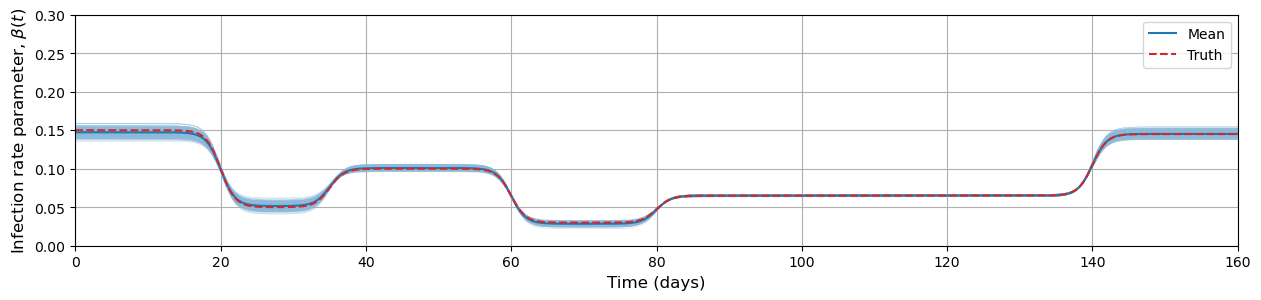

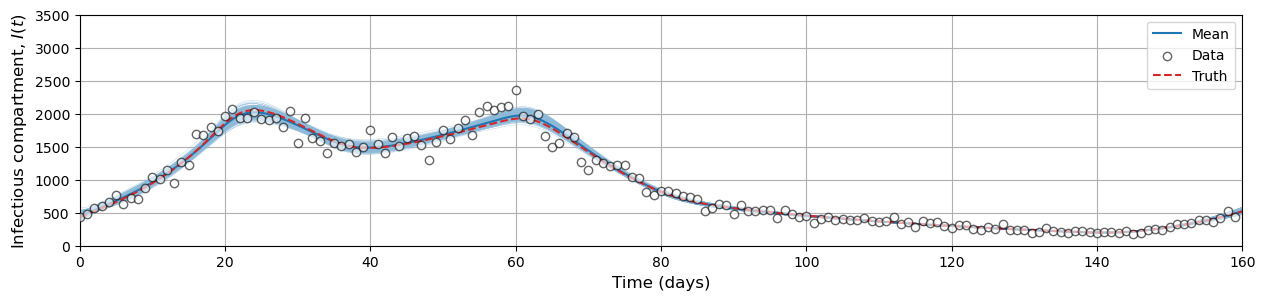

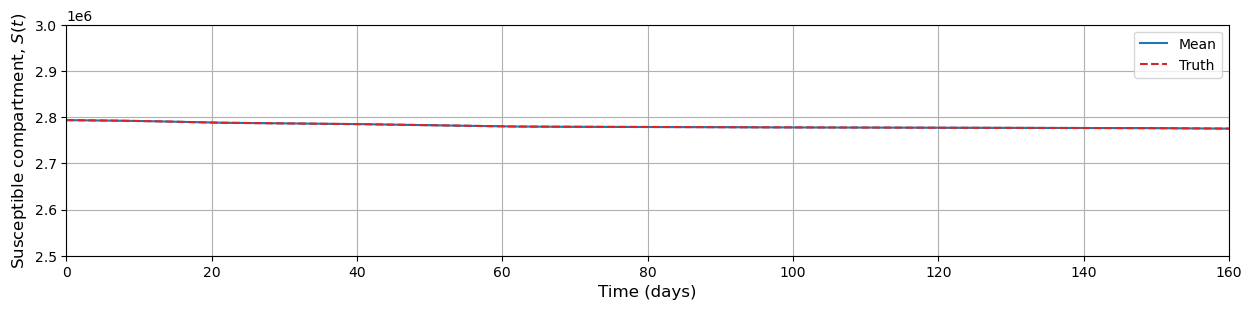

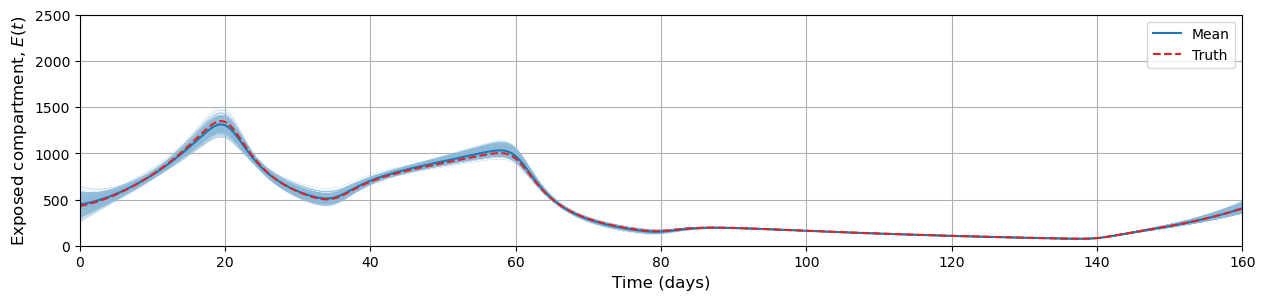

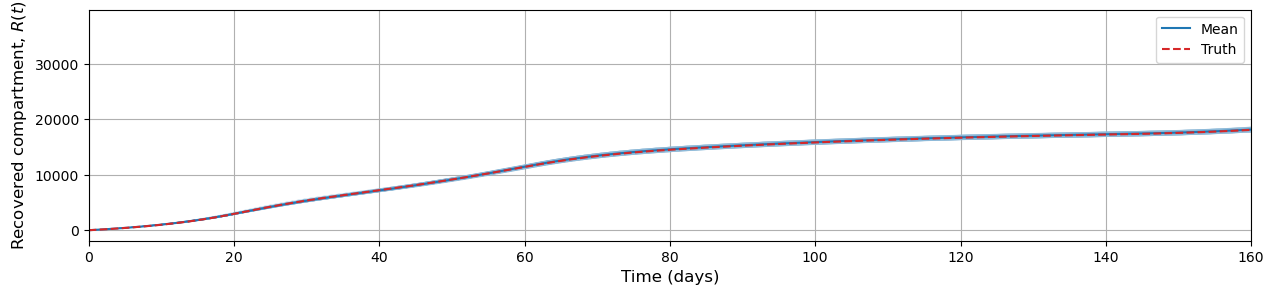

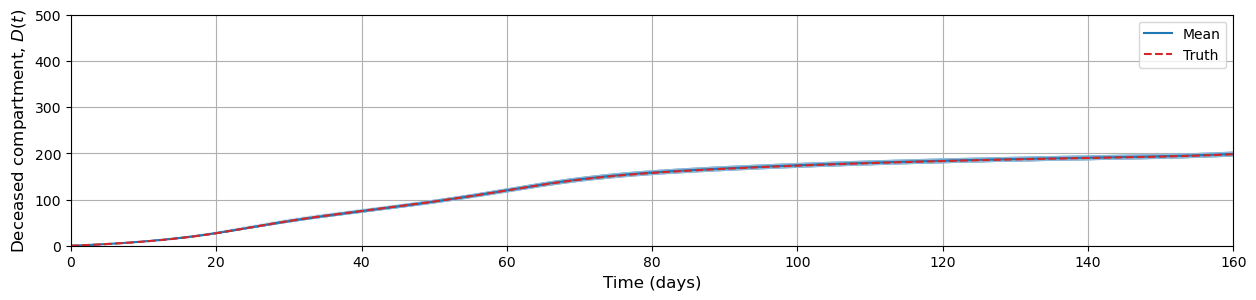

In [5]:
##### Printing beta samples

pred_low = int(tstart*ndiv)

pred_high = int(tlim*ndiv)

Nsamples = 500


for ns in range(Nsamples):


### Toronto
    a0 = samples[0,ns]
    a1 = samples[1,ns]
    t1 =  20
    a2 = samples[2,ns]
    t2 =  35
    a3 =  samples[3,ns]
    t3 = 60
    a4 =  samples[4,ns]
    t4 = 80
    a5 =  samples[5,ns]
    t5 =  140
  

    # a6 =  samples[6,ns]
    # t6 = 180
    # a7 =  samples[7,ns]
    # t7 =  190

    # Initial Conditions
    ####### CHANGE HERE ######################
    E[0,0] = samples[6,ns]
    I[0,0] = samples[7,ns]
    #####################################
    R[0,0] = 0
    D[0,0] = 0
    N[0,0] = total[0]
    S[0,0] = N[0,0] - E[0,0] - I[0,0] - R[0,0] - D[0,0]


    beta_i[:,0] = a0 + a1/(1 + np.exp((t1-tmoh))) +  a2/(1 + np.exp((t2-tmoh))) + a3/(1 + np.exp((t3-tmoh)))  + a4/(1 + np.exp((t4-tmoh))) + a5/(1 + np.exp((t5-tmoh))) \
    # + a6/(1 + np.exp((t6-tmoh))) + a7/(1 + np.exp((t7-tmoh))) 
                # + a8/(1 + np.exp((t8-tmoh)))
    beta_e[:,0] = beta_i[:,0]

    if ns == 0:
        beta_append=beta_e
    else:
        beta_append=np.hstack((beta_append,beta_e))


    idxmoh = 0


    FoI = np.zeros((len(tmoh),1))
        
    for kk in range(1,len(tmoh)):

        FoI[kk,0] = beta_e[kk-1,0] * (E[kk-1,0] + I[kk-1,0]) / N[kk-1,0]

        S[kk,0] = S[kk-1,0] + dt*(- FoI[kk,0] * S[kk-1,0])
        E[kk,0] = E[kk-1,0] + dt*(FoI[kk,0]*S[kk-1,0] - (gamma_i + gamma_e)*E[kk-1,0])
        
        I[kk,0] = I[kk-1,0] + dt*(gamma_i*E[kk-1,0] - (gamma_r + gamma_d)*I[kk-1,0])
        R[kk,0] = R[kk-1,0] + dt*(gamma_e*E[kk-1,0] + gamma_r*I[kk-1,0])
        D[kk,0] = D[kk-1,0] + dt*(gamma_d*I[kk-1,0])
        N[kk,0] = S[kk,0] +  E[kk,0] + I[kk,0] + R[kk,0]

    if ns == 0:
        s_append=S[:,0]
        e_append=E[:,0]
        i_append=I[:,0]
        r_append=R[:,0]
        d_append=D[:,0]
    else:
        s_append=np.vstack((s_append,S[:,0]))
        e_append=np.vstack((e_append,E[:,0]))
        i_append=np.vstack((i_append,I[:,0]))
        r_append=np.vstack((r_append,R[:,0]))
        d_append=np.vstack((d_append,D[:,0]))

s_append=s_append.T
e_append=e_append.T
i_append=i_append.T
r_append=r_append.T
d_append=d_append.T


mpl.rcParams.update({'font.size':10})
fig1, ax1 = plt.subplots(figsize=(15, 3))
ax1.set_xlabel('Time (days)', fontsize=12)
ax1.set_ylabel(r'Infection rate parameter, $\beta(t)$', fontsize=12)
ax1.plot(tmoh[pred_low:pred_high], beta_append[pred_low:pred_high,:], color=(142/255,186/255,217/255), linewidth=0.2, label='_nolegend_')
ax1.plot(tmoh[pred_low:pred_high], beta_mean[pred_low:pred_high,0], color='tab:blue',linestyle='-', label='Mean')
ax1.plot(tmoh[pred_low:pred_high], beta_truth[pred_low:pred_high], color='tab:red',linestyle='--', label='Truth')
ax1.legend()
ax1.grid()
plt.xlim([0,160])
plt.ylim([0,0.3])
ax1.figure.savefig(f'{figpath}/beta_synthetic_uncertainty.pdf', bbox_inches='tight')
# ax1.figure.savefig(f'{figpath}/beta_real_uncertainty_case2.pdf', bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(15, 3))
ax2.set_xlabel('Time (days)', fontsize=12)
ax2.set_ylabel(r'Infectious compartment, $I(t)$', fontsize=12)
ax2.plot(tmoh[pred_low:pred_high], i_append[pred_low:pred_high,:], color=(142/255,186/255,217/255), linewidth=0.2, label='_nolegend_')
ax2.plot(tmoh[pred_low:pred_high], I_mean[pred_low:pred_high,0], color='tab:blue',linestyle='-', label='Mean')
plt.scatter(t_data[0:160],x_data[0:160],color='w',edgecolors='k',zorder=3,alpha=0.6,label='Data')
ax2.plot(tmoh[pred_low:pred_high], all_truth[pred_low:pred_high,2], color='tab:red',linestyle='--', label='Truth')
ax2.legend()
ax2.grid()
plt.xlim([0,160])
plt.ylim([0,3500])
ax2.figure.savefig(f'{figpath}/i_synthetic_uncertainty.pdf', bbox_inches='tight')
# ax2.figure.savefig(f'{figpath}/i_real_uncertainty_case2.pdf', bbox_inches='tight')
plt.show()



fig3, ax3 = plt.subplots(figsize=(15, 3))
ax3.set_xlabel('Time (days)', fontsize=12)
ax3.set_ylabel(r'Susceptible compartment, $S(t)$', fontsize=12)
ax3.plot(tmoh[pred_low:pred_high], s_append[pred_low:pred_high,:], color=(142/255,186/255,217/255), linewidth=0.2, label='_nolegend_')
ax3.plot(tmoh[pred_low:pred_high], S_mean[pred_low:pred_high,0], color='tab:blue',linestyle='-', label='Mean')
ax3.plot(tmoh[pred_low:pred_high], all_truth[pred_low:pred_high,0], color='tab:red',linestyle='--', label='Truth')
# plt.scatter(t_data,x_data[0:160],color='w',edgecolors='k',zorder=1,alpha=0.6,label='Data')
ax3.legend()
ax3.grid()
plt.xlim([0,160])
plt.ylim([2.5e6,3e6])
# ax3.figure.savefig(f'{figpath}/s_synthetic_uncertainty.pdf', bbox_inches='tight')
ax3.figure.savefig(f'{figpath}/s_synthetic_uncertainty.pdf', bbox_inches='tight')
plt.show()




fig4, ax4 = plt.subplots(figsize=(15, 3))
ax4.set_xlabel('Time (days)', fontsize=12)
ax4.set_ylabel(r'Exposed compartment, $E(t)$', fontsize=12)
ax4.plot(tmoh[pred_low:pred_high], e_append[pred_low:pred_high,:], color=(142/255,186/255,217/255), linewidth=0.2, label='_nolegend_')
ax4.plot(tmoh[pred_low:pred_high], E_mean[pred_low:pred_high,0], color='tab:blue',linestyle='-', label='Mean')
ax4.plot(tmoh[pred_low:pred_high], all_truth[pred_low:pred_high,1], color='tab:red',linestyle='--', label='Truth')
# plt.scatter(t_data,x_data[0:160],color='w',edgecolors='k',zorder=1,alpha=0.6,label='Data')
ax4.legend()
ax4.grid()
plt.xlim([0,160])
plt.ylim([0,2500])
# ax4.figure.savefig(f'{figpath}/e_synthetic_uncertainty.pdf', bbox_inches='tight')
ax4.figure.savefig(f'{figpath}/e_synthetic_uncertainty.pdf', bbox_inches='tight')
plt.show()



fig5, ax5 = plt.subplots(figsize=(15, 3))
ax5.set_xlabel('Time (days)', fontsize=12)
ax5.set_ylabel(r'Recovered compartment, $R(t)$', fontsize=12)
ax5.plot(tmoh[pred_low:pred_high], r_append[pred_low:pred_high,:], color=(142/255,186/255,217/255), linewidth=0.2, label='_nolegend_')
ax5.plot(tmoh[pred_low:pred_high], R_mean[pred_low:pred_high,0], color='tab:blue',linestyle='-', label='Mean')
ax5.plot(tmoh[pred_low:pred_high], all_truth[pred_low:pred_high,3], color='tab:red',linestyle='--', label='Truth')
# plt.scatter(t_data,x_data[0:160],color='w',edgecolors='k',zorder=1,alpha=0.6,label='Data')
ax5.legend()
ax5.grid()
plt.xlim([0,160])
# plt.ylim([0,3500])
ax5.figure.savefig(f'{figpath}/r_synthetic_uncertainty.pdf', bbox_inches='tight')
# ax5.figure.savefig(f'{figpath}/r_real_uncertainty_case2.pdf', bbox_inches='tight')
plt.show()


fig6, ax6 = plt.subplots(figsize=(15, 3))
ax6.set_xlabel('Time (days)', fontsize=12)
ax6.set_ylabel(r'Deceased compartment, $D(t)$', fontsize=12)
ax6.plot(tmoh[pred_low:pred_high], d_append[pred_low:pred_high,:], color=(142/255,186/255,217/255), linewidth=0.2, label='_nolegend_')
ax6.plot(tmoh[pred_low:pred_high], D_mean[pred_low:pred_high,0], color='tab:blue',linestyle='-', label='Mean')
ax6.plot(tmoh[pred_low:pred_high], all_truth[pred_low:pred_high,4], color='tab:red',linestyle='--', label='Truth')
# plt.scatter(t_data,x_data[0:160],color='w',edgecolors='k',zorder=1,alpha=0.6,label='Data')
ax6.legend()
ax6.grid()
plt.xlim([0,160])
plt.ylim([0,500])
ax6.figure.savefig(f'{figpath}/d_synthetic_uncertainty.pdf', bbox_inches='tight')
# ax6.figure.savefig(f'{figpath}/d_real_uncertainty_case2.pdf', bbox_inches='tight')
plt.show()

### Code to plot forecast with uncertainty bounds

(400, 500)
(400, 500)


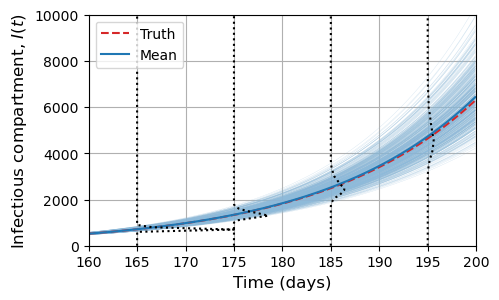

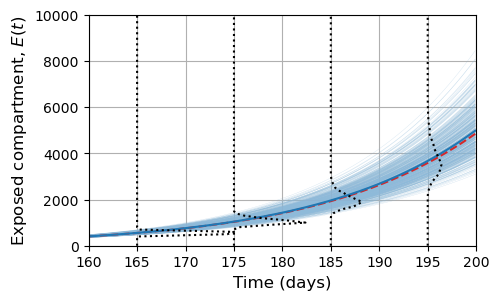

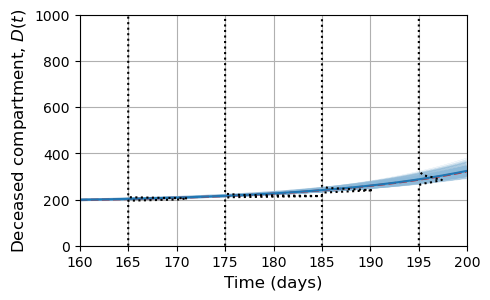

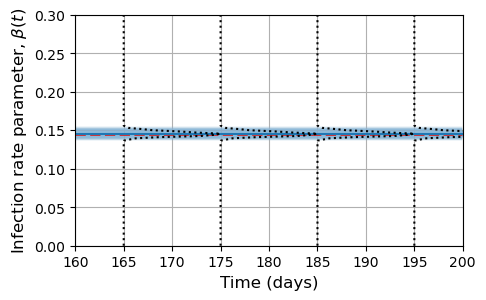

In [ ]:
d_cut = 160

pred_low = int(d_cut*ndiv)

pred_high = int(tlim*ndiv)

Nsamples = 500

for ns in range(Nsamples):


##### For Toronto
    a0 = samples[0,ns]
    a1 = samples[1,ns]
    t1 =  20
    a2 = samples[2,ns]
    t2 =  35
    a3 =  samples[3,ns]
    t3 = 60
    a4 =  samples[4,ns]
    t4 = 80
    a5 =  samples[5,ns]
    t5 =  140


    # a6 =  samples[6,ns]
    # t6 = 180
    # a7 =  samples[7,ns]
    # t7 =  190

    # Initial Conditions
    ####### CHANGE HERE ######################
    E[0,0] = samples[6,ns]
    I[0,0] = samples[7,ns]
    #####################################
    R[0,0] = 0
    D[0,0] = 0
    N[0,0] = total[0]
    S[0,0] = N[0,0] - E[0,0] - I[0,0] - R[0,0] - D[0,0]

    beta_i[:,0] = a0 + a1/(1 + np.exp((t1-tmoh))) +  a2/(1 + np.exp((t2-tmoh))) + a3/(1 + np.exp((t3-tmoh)))  + a4/(1 + np.exp((t4-tmoh))) + a5/(1 + np.exp((t5-tmoh))) \
    # + a6/(1 + np.exp((t6-tmoh))) + a7/(1 + np.exp((t7-tmoh))) 
    # + a8/(1 + np.exp((t8-tmoh)))
    beta_e[:,0] = beta_i[:,0]

    if ns == 0:
        beta_append=beta_e
    else:
        beta_append=np.hstack((beta_append,beta_e))


    idxmoh = 0


    FoI = np.zeros((len(tmoh),1))
        
    for kk in range(1,len(tmoh)):

        FoI[kk,0] = beta_e[kk-1,0] * (E[kk-1,0] + I[kk-1,0]) / N[kk-1,0]

        S[kk,0] = S[kk-1,0] + dt*(- FoI[kk,0] * S[kk-1,0])
        E[kk,0] = E[kk-1,0] + dt*(FoI[kk,0]*S[kk-1,0] - (gamma_i + gamma_e)*E[kk-1,0])
        
        I[kk,0] = I[kk-1,0] + dt*(gamma_i*E[kk-1,0] - (gamma_r + gamma_d)*I[kk-1,0])
        R[kk,0] = R[kk-1,0] + dt*(gamma_e*E[kk-1,0] + gamma_r*I[kk-1,0])
        D[kk,0] = D[kk-1,0] + dt*(gamma_d*I[kk-1,0])
        N[kk,0] = S[kk,0] +  E[kk,0] + I[kk,0] + R[kk,0]


    if ns == 0:
        s_append=S[:,0]
        e_append=E[:,0]
        i_append=I[:,0]
        r_append=R[:,0]
        d_append=D[:,0]
    else:
        s_append=np.vstack((s_append,S[:,0]))
        e_append=np.vstack((e_append,E[:,0]))
        i_append=np.vstack((i_append,I[:,0]))
        r_append=np.vstack((r_append,R[:,0]))
        d_append=np.vstack((d_append,D[:,0]))


s_append=s_append.T
e_append=e_append.T
i_append=i_append.T
r_append=r_append.T
d_append=d_append.T

print(np.shape(i_append[pred_low:pred_high,:]))
print(np.shape(beta_append[pred_low:pred_high,:]))

Igrd = np.linspace(0,20000,201)
Ipdf_0 = st.gaussian_kde(i_append[1650,:],bw_method = 0.2)
Ipdf_5 = st.gaussian_kde(i_append[1750,:],bw_method = 0.2)
Ipdf_10 = st.gaussian_kde(i_append[1850,:],bw_method = 0.2)
Ipdf_15 = st.gaussian_kde(i_append[1950,:],bw_method = 0.2)
# Ipdf_20 = st.gaussian_kde(i_append[2000,:],bw_method = 0.2)
Imax = np.max([Ipdf_0(Igrd),Ipdf_5(Igrd),Ipdf_10(Igrd),Ipdf_15(Igrd)])
# Imax = np.max([Ipdf_0(Igrd),Ipdf_5(Igrd),Ipdf_10(Igrd),Ipdf_15(Igrd),Ipdf_20(Igrd)])


Egrd = np.linspace(0,20000,201)
Epdf_0 = st.gaussian_kde(e_append[1650,:],bw_method = 0.2)
Epdf_5 = st.gaussian_kde(e_append[1750,:],bw_method = 0.2)
Epdf_10 = st.gaussian_kde(e_append[1850,:],bw_method = 0.2)
Epdf_15 = st.gaussian_kde(e_append[1950,:],bw_method = 0.2)
# Ipdf_20 = st.gaussian_kde(i_append[2000,:],bw_method = 0.2)
Emax = np.max([Epdf_0(Egrd),Epdf_5(Egrd),Epdf_10(Egrd),Epdf_15(Egrd)])
# Imax = np.max([Ipdf_0(Igrd),Ipdf_5(Igrd),Ipdf_10(Igrd),Ipdf_15(Igrd),Ipdf_20(Igrd)])



Dgrd = np.linspace(0,1000,201)
Dpdf_0 = st.gaussian_kde(d_append[1650,:],bw_method = 0.2)
Dpdf_5 = st.gaussian_kde(d_append[1750,:],bw_method = 0.2)
Dpdf_10 = st.gaussian_kde(d_append[1850,:],bw_method = 0.2)
Dpdf_15 = st.gaussian_kde(d_append[1950,:],bw_method = 0.2)
# Ipdf_20 = st.gaussian_kde(i_append[2000,:],bw_method = 0.2)
Dmax = np.max([Dpdf_0(Dgrd),Dpdf_5(Dgrd),Dpdf_10(Dgrd),Dpdf_15(Dgrd)])
# Imax = np.max([Ipdf_0(Igrd),Ipdf_5(Igrd),Ipdf_10(Igrd),Ipdf_15(Igrd),Ipdf_20(Igrd)])



Bgrd = np.linspace(0,0.3,201)
Bpdf_0 = st.gaussian_kde(beta_append[1650,:],bw_method = 0.2)
Bpdf_5 = st.gaussian_kde(beta_append[1750,:],bw_method = 0.2)
Bpdf_10 = st.gaussian_kde(beta_append[1850,:],bw_method = 0.2)
Bpdf_15 = st.gaussian_kde(beta_append[1950,:],bw_method = 0.2)
# Bpdf_20 = st.gaussian_kde(beta_append[2000,:],bw_method = 0.2)
Bmax = np.max([Bpdf_0(Igrd),Bpdf_5(Bgrd),Bpdf_10(Bgrd),Bpdf_15(Bgrd)])
# Bmax = np.max([Bpdf_0(Bgrd),Bpdf_5(Bgrd),Bpdf_10(Bgrd),Bpdf_15(Bgrd),Ipdf_20(Bgrd)])



# # Loading previously created arrays for the estimated truth bounds
# i_upper = np.loadtxt("i_upper.csv", delimiter=",")
# i_lower = np.loadtxt("i_lower.csv", delimiter=",")

# e_upper = np.loadtxt("e_upper.csv", delimiter=",")
# e_lower = np.loadtxt("e_lower.csv", delimiter=",")

# beta_upper = np.loadtxt("beta_upper.csv", delimiter=",")
# beta_lower = np.loadtxt("beta_lower.csv", delimiter=",")



t_data = np.arange(0,201)

f, ax = plt.subplots(1, figsize=(5,3))#15,3
plt.plot(tmoh[pred_low:pred_high], i_append[pred_low:pred_high,:], color=(142/255,186/255,217/255,0.5), linewidth=0.2, label='_nolegend_')
plt.plot(tmoh[pred_low:pred_high], all_truth[pred_low:pred_high,2], color='tab:red',linestyle='--', label='Truth')


# plt.plot(tmoh[pred_low:pred_high],i_upper[pred_low:pred_high], color='red',alpha=0.5, linestyle=':')
# plt.plot(tmoh[pred_low:pred_high],i_lower[pred_low:pred_high],color='red', alpha=0.5, linestyle=':')

# plt.scatter(t_data[160:200],x_data[160:200],color='w',edgecolors='k',zorder=3,alpha=0.4,label='Data')
plt.plot(tmoh[pred_low:pred_high], I_mean[pred_low:pred_high,0], color='tab:blue',linestyle='-', label='Mean')
plt.grid(True)
plt.plot(165+Ipdf_0(Igrd)*10/Imax,Igrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
plt.plot(175+Ipdf_5(Igrd)*10/Imax,Igrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
plt.plot(185+Ipdf_10(Igrd)*10/Imax,Igrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
plt.plot(195+Ipdf_15(Igrd)*10/Imax,Igrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
# plt.plot(200+Ipdf_20(Igrd)*10/Imax,Igrd*2794356,linewidth=1.5,c='k',linestyle=':',zorder=3)
# plt.xticks([272, 279, 286,293,300])
plt.xlim([160,200])
plt.ylim([0,1e4])
plt.xlabel('Time (days)', fontsize=12)
plt.ylabel(r'Infectious compartment, $I(t)$', fontsize=12)
ax.legend(loc='upper left')
# ax.legend(loc='upper left', bbox_to_anchor=(0.5, -0.25), fancybox=True, shadow=True, ncol=3, fontsize=12)
plt.savefig(f'{figpath}/forecast_i_synth_noise10_initial_sigmoid.pdf',bbox_inches='tight')






f, ax = plt.subplots(1, figsize=(5,3))#15,3
plt.plot(tmoh[pred_low:pred_high], e_append[pred_low:pred_high,:], color=(142/255,186/255,217/255,0.5), linewidth=0.2, label='_nolegend_')
plt.plot(tmoh[pred_low:pred_high], all_truth[pred_low:pred_high,1], color='tab:red',linestyle='--', label='Truth')


# plt.plot(tmoh[pred_low:pred_high],e_upper[pred_low:pred_high], color='red',alpha=0.5, linestyle=':')
# plt.plot(tmoh[pred_low:pred_high],e_lower[pred_low:pred_high],color='red', alpha=0.5, linestyle=':')

plt.plot(tmoh[pred_low:pred_high], E_mean[pred_low:pred_high,0], color='tab:blue',linestyle='-', label='Mean')
plt.grid(True)
plt.plot(165+Epdf_0(Egrd)*10/Emax,Egrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
plt.plot(175+Epdf_5(Egrd)*10/Emax,Egrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
plt.plot(185+Epdf_10(Egrd)*10/Emax,Egrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
plt.plot(195+Epdf_15(Egrd)*10/Emax,Egrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
# plt.plot(200+Ipdf_20(Igrd)*10/Imax,Igrd*2794356,linewidth=1.5,c='k',linestyle=':',zorder=3)
# plt.xticks([272, 279, 286,293,300])
plt.xlim([160,200])
plt.ylim([0,1e4])
plt.xlabel('Time (days)', fontsize=12)
plt.ylabel(r'Exposed compartment, $E(t)$', fontsize=12)
# ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), fancybox=True, shadow=True, ncol=3, fontsize=12)
plt.savefig(f'{figpath}/forecast_e_synth_noise10_initial_sigmoid.pdf',bbox_inches='tight')




# f, ax = plt.subplots(1, figsize=(5,3))#15,3
# plt.plot(tmoh[pred_low:pred_high], d_append[pred_low:pred_high,:], color=(142/255,186/255,217/255,0.5), linewidth=0.2, label='_nolegend_')
# plt.plot(tmoh[pred_low:pred_high], all_truth[pred_low:pred_high,4], color='tab:red',linestyle='--', label='Truth')
# plt.plot(tmoh[pred_low:pred_high], D_mean[pred_low:pred_high,0], color='tab:blue',linestyle='-', label='Mean')
# plt.grid(True)
# plt.plot(165+Dpdf_0(Dgrd)*10/Dmax,Dgrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
# plt.plot(175+Dpdf_5(Dgrd)*10/Dmax,Dgrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
# plt.plot(185+Dpdf_10(Dgrd)*10/Dmax,Dgrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
# plt.plot(195+Dpdf_15(Dgrd)*10/Dmax,Dgrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
# # plt.plot(200+Ipdf_20(Igrd)*10/Imax,Igrd*2794356,linewidth=1.5,c='k',linestyle=':',zorder=3)
# # plt.xticks([272, 279, 286,293,300])
# plt.xlim([160,200])
# plt.ylim([0,1000])
# plt.xlabel('Time (days)', fontsize=12)
# plt.ylabel(r'Deceased compartment, $D(t)$', fontsize=12)
# # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), fancybox=True, shadow=True, ncol=3, fontsize=12)
# plt.savefig(f'{figpath}/forecast_d_synth_noise10_initial_sigmoid.pdf',bbox_inches='tight')





f, ax = plt.subplots(1, figsize=(5,3))#15,3
plt.plot(tmoh[pred_low:pred_high], beta_append[pred_low:pred_high,:], color=(142/255,186/255,217/255,0.5), linewidth=0.2, label='_nolegend_')
plt.plot(tmoh[pred_low:pred_high], beta_truth[pred_low:pred_high],linewidth=2,c='tab:red',linestyle='--', label='Truth')


# plt.plot(tmoh[pred_low:pred_high],beta_upper[pred_low:pred_high], color='red',alpha=0.5, linestyle=':')
# plt.plot(tmoh[pred_low:pred_high],beta_lower[pred_low:pred_high],color='red', alpha=0.5, linestyle=':')

plt.plot(tmoh[pred_low:pred_high], beta_mean[pred_low:pred_high,0], color='tab:blue',linestyle='-', label='Mean')
plt.grid(True)
# plt.xticks([272, 279, 286,293,300])
plt.plot(165+Bpdf_0(Bgrd)*10/Bmax,Bgrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
plt.plot(175+Bpdf_5(Bgrd)*10/Bmax,Bgrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
plt.plot(185+Bpdf_10(Bgrd)*10/Bmax,Bgrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
plt.plot(195+Bpdf_15(Bgrd)*10/Bmax,Bgrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
# plt.plot(200+Bpdf_20(Bgrd)*10/Bmax,Bgrd,linewidth=1.5,c='k',linestyle=':',zorder=3)
plt.xlim([160,200])
plt.ylim([0,0.3])
plt.xlabel('Time (days)', fontsize=12)
plt.ylabel(r'Infection rate parameter, $\beta(t)$', fontsize=12)
# ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), fancybox=True, shadow=True, ncol=3, fontsize=12)
plt.savefig(f'{figpath}/forecast_beta_synth_noise10_initial_sigmoid.pdf',bbox_inches='tight')


### Code to Plot Joint PDFs of Parameters

/var/folders/lr/4h04vl_92s3d0hrwg37l8g740000gn/T/ipykernel_19819/3069485393.py:24: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  res = minimize(kde_fun,true, method='nelder-mead',options={'xatol': 1e-8, 'disp': True})


0.14731462535108467 0.003743593439738851 0.14536163796204574
-0.09580503383918489 0.006483697170068706 -0.0923651162730208
0.04940553199472126 0.004996863285605365 0.04745263866064328


/var/folders/lr/4h04vl_92s3d0hrwg37l8g740000gn/T/ipykernel_19819/3069485393.py:73: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  f, ax = plt.subplots(1, figsize=(3,3))


-0.07240766436924986 0.0034981758185999618 -0.0717142846178345
0.036509699214998845 0.002252053667865244 0.03631960159581166
0.08022319405240759 0.0035787962797025983 0.07999104403476756
445.9180939669869 68.25838606081996 477.38344234277736
444.11074609433564 37.26269183826283 430.4860589275286


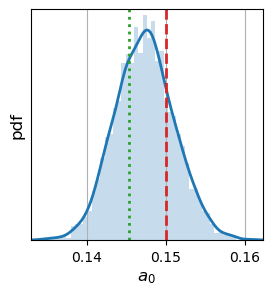

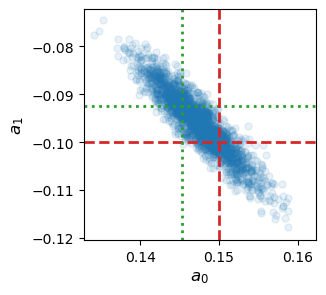

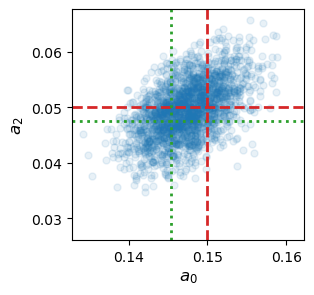

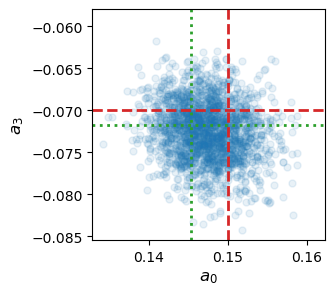

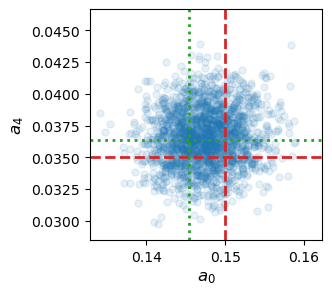

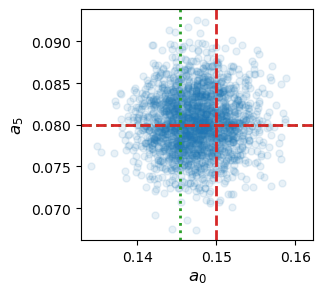

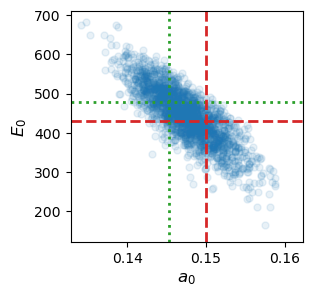

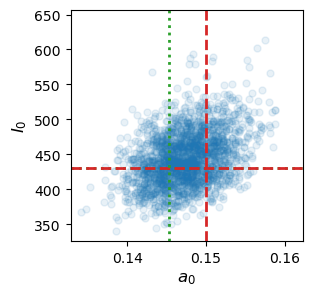

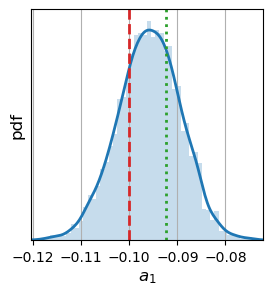

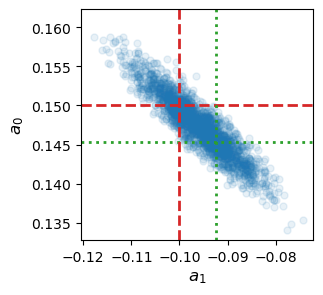

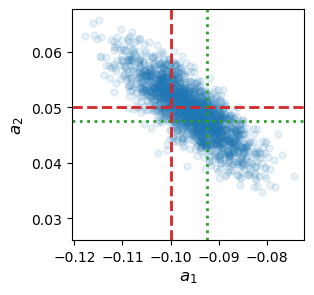

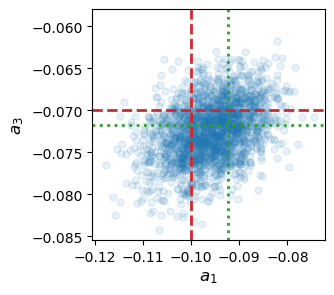

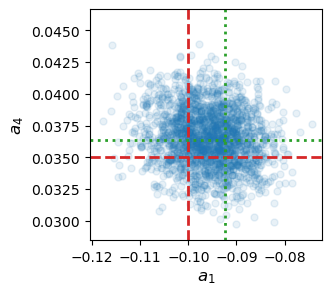

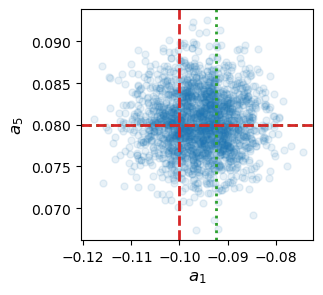

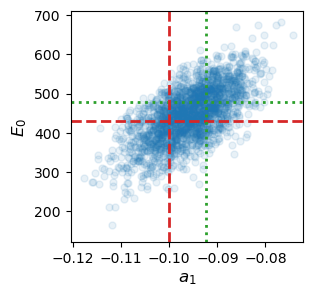

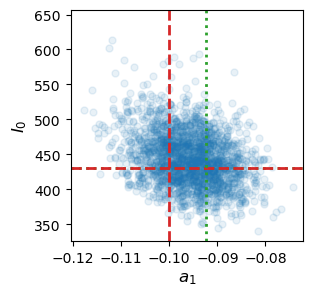

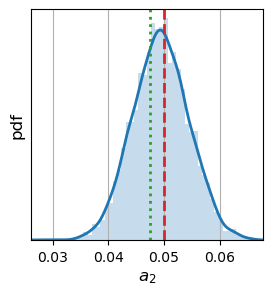

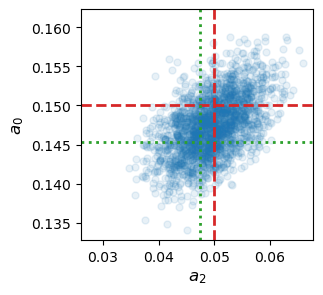

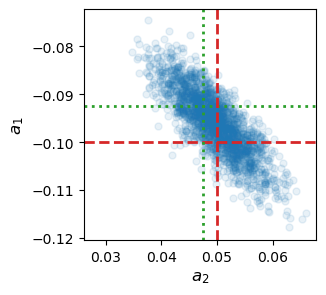

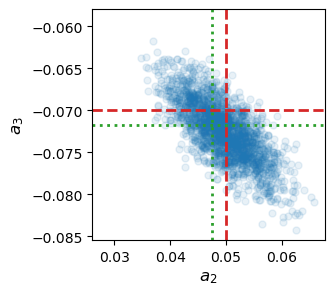

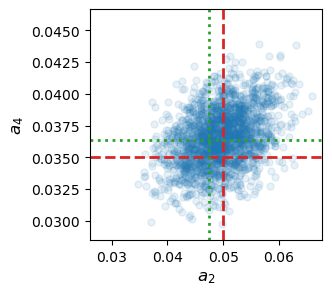

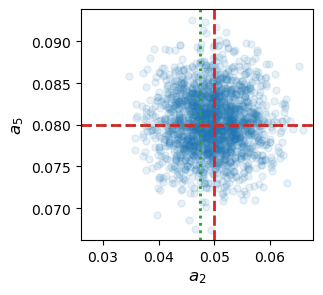

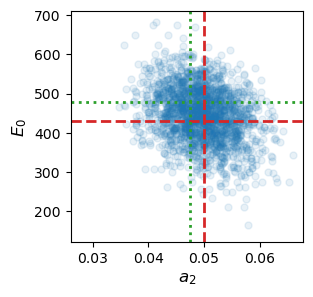

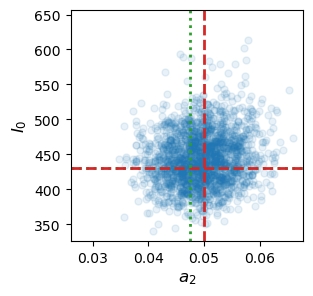

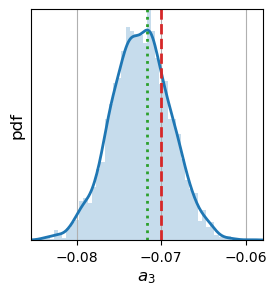

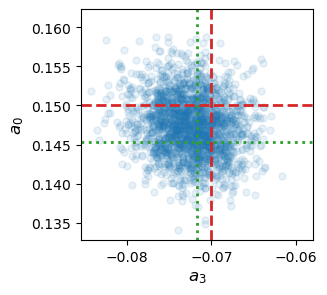

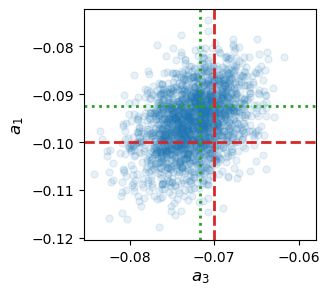

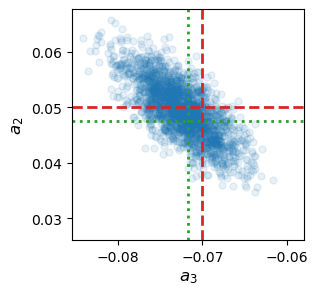

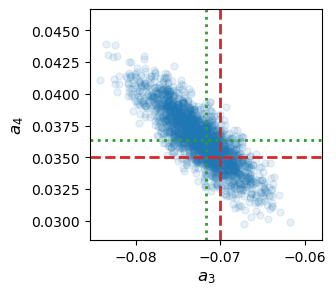

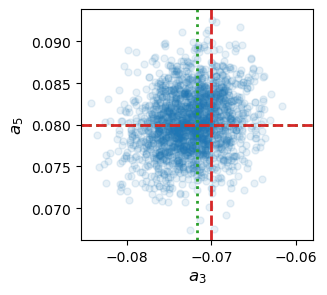

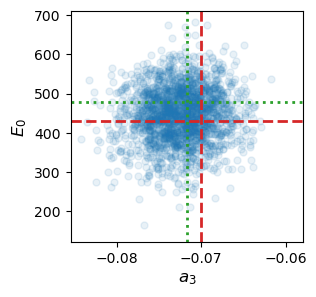

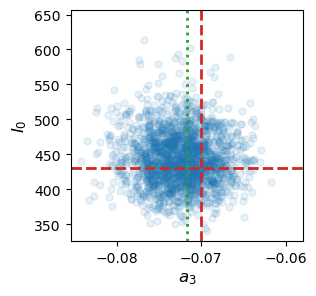

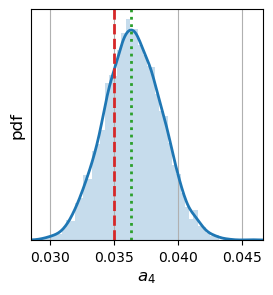

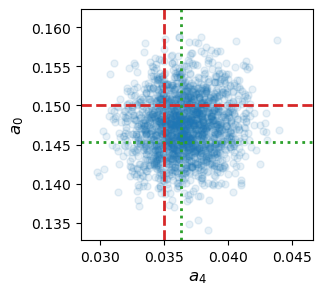

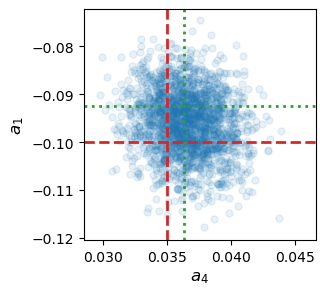

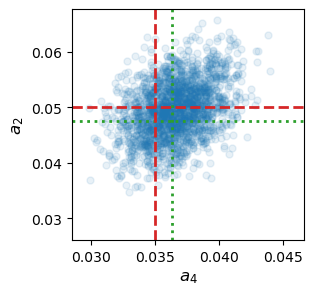

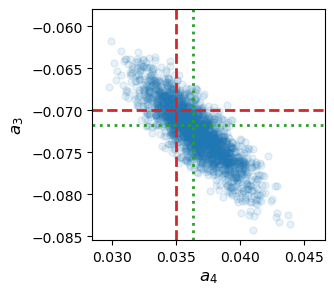

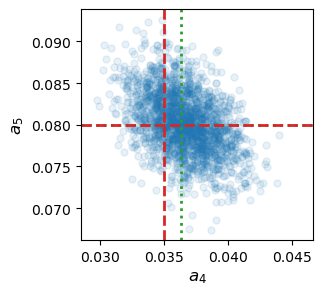

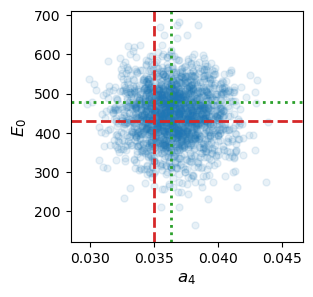

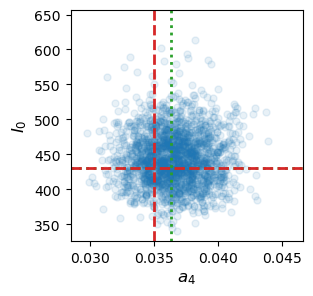

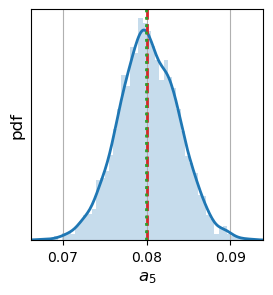

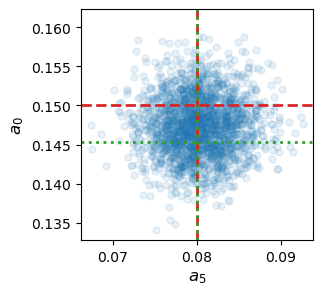

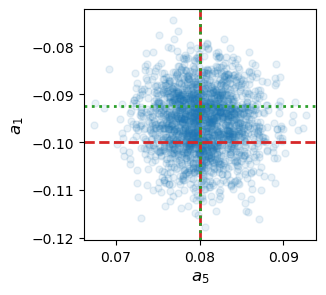

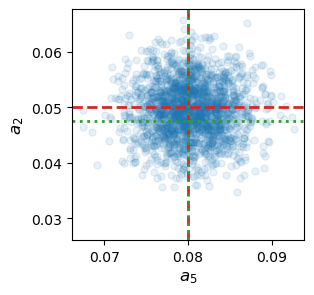

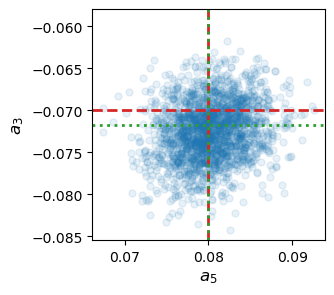

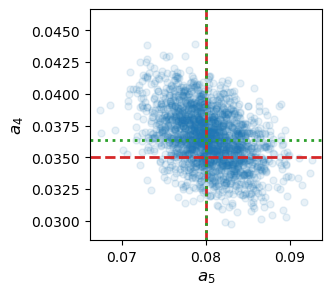

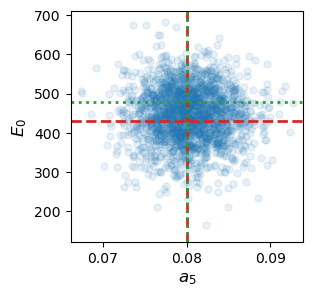

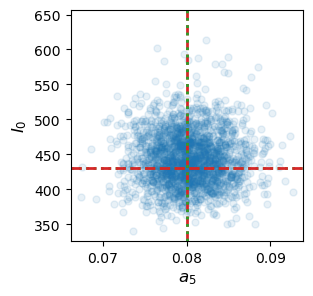

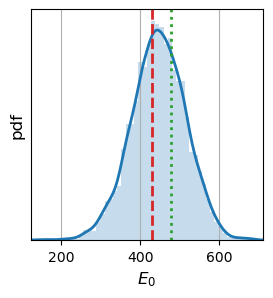

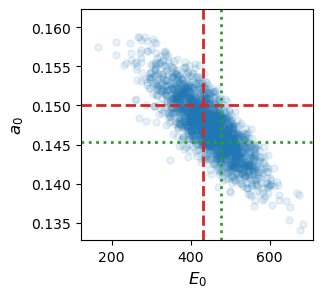

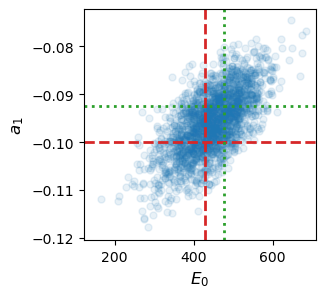

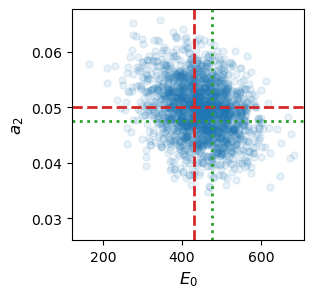

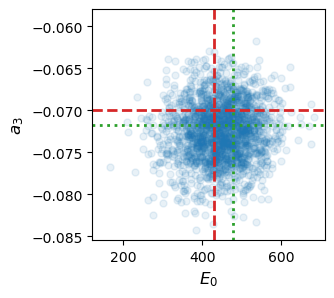

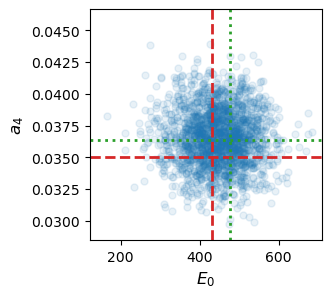

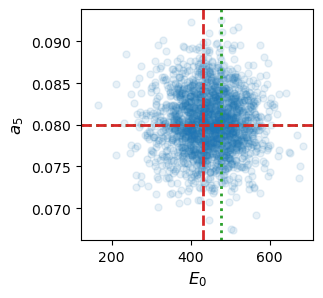

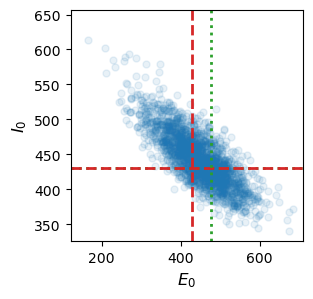

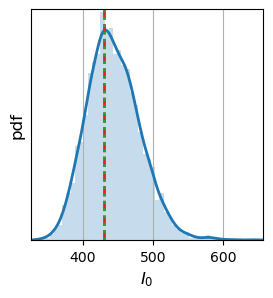

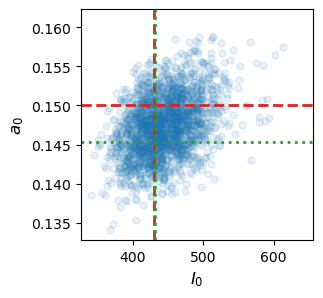

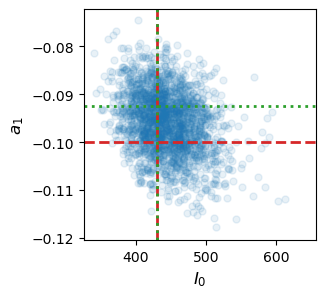

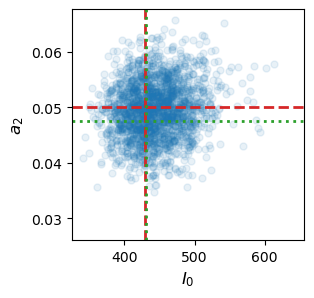

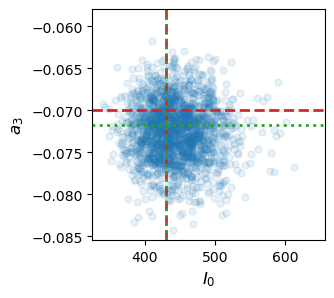

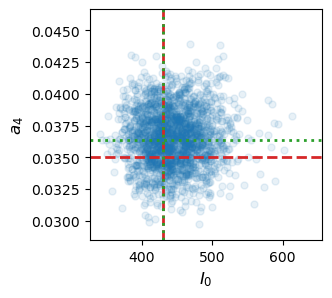

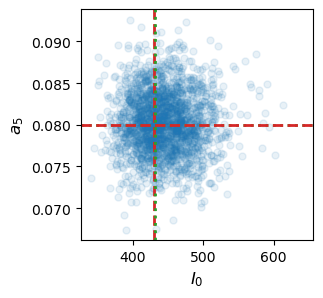

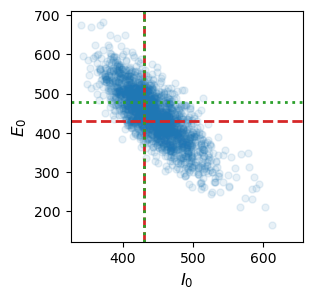

In [7]:
## Model Full
skip = 2

# samples = np.loadtxt('../../data/muVec_real_noise10_initial.dat')
samples = np.loadtxt('../../data/muVec_synth_noise10_initial.dat')


label = [r'$a_0$',r'$a_1$',r'$a_2$',r'$a_3$',r'$a_4$',r'$a_5$',r'$E_0$', r'$I_0$']
Npar = len(samples[:,0])

## ### For synthetic data CASE 1
true = [0.15,-0.1,0.05,-0.07,0.035,0.08, 430, 430]

### For real data
# true = [0.145,-0.11,0.057,-0.061,0.022,0.089,500,390]


find_map = 1
if find_map == 1:
  from scipy.optimize import minimize
  kde = st.gaussian_kde(samples)
  def kde_fun(x):
    return -kde(x)
  res = minimize(kde_fun,true, method='nelder-mead',options={'xatol': 1e-8, 'disp': True})
  # print(res.x)
  maps = res.x
  # np.savetxt('chains/ModelSIRS_SIS-map.dat',maps)

for ii in range(len(samples[:,0])):
  xmin,xmax = np.min(samples[ii,:]), np.max(samples[ii,:])
  # if param_true[ii] < xmin:
  #   xmin = param_true[ii]
  # elif  param_true[ii] > xmax:
  #   xmax = param_true[ii]

  print(np.mean(samples[ii,:]),np.std(samples[ii,:]),maps[ii])

  xmean = (xmin + xmax)/2
  xrang = (xmax - xmin)
  x_low = np.max([xmean-0.55*xrang])
  x_up = np.min([xmean+0.55*xrang])

  f, ax = plt.subplots(1, figsize=(3,3))
  Xpdf = st.gaussian_kde(samples[ii,:],bw_method = 0.2)
  # print(Xpdf.silverman_factor())
  # Xgrd = np.linspace(np.min(samples[ii,:]),np.max(samples[ii,:]))
  Xgrd = np.linspace(x_low,x_up,201)
  pdfmax = max(Xpdf(Xgrd))
  plt.plot(Xgrd,Xpdf(Xgrd),color='tab:blue',linewidth=2)
  plt.hist(samples[ii,:],bins=50,density=True,alpha=0.25)

  ### Uncomment for Synthetic data
  plt.plot([true[ii],true[ii]],[0,1.1*pdfmax],c='tab:red',linewidth=2,linestyle='--')
  plt.plot([maps[ii],maps[ii]],[0,1.1*pdfmax],c='tab:green',linewidth=2,linestyle=':')
  myYlim = [0.0, 1.1*pdfmax]
  plt.ylabel('pdf', fontsize=12)
  plt.xlabel(label[ii], fontsize=12)
  plt.ylim(myYlim)
  plt.xlim([x_low,x_up])
  plt.yticks([])
  plt.grid(True)
  plt.savefig(f'{figpath}/synth_MAP_mpdf_'+ str(ii)+'.pdf',bbox_inches='tight')
  # plt.close()

  for jj in range(Npar):
   if ii != jj:
      ymin,ymax = np.min(samples[jj,:]), np.max(samples[jj,:])
      ymean = (ymin + ymax)/2
      yrang = (ymax - ymin)
      y_low = np.max([ymean-0.55*yrang])
      y_up = np.min([ymean+0.55*yrang])

      f, ax = plt.subplots(1, figsize=(3,3))
      plt.scatter(samples[ii,::skip],samples[jj,::skip],alpha=0.1,s=25)
      plt.plot([x_low,x_up],[maps[jj],maps[jj]],c='tab:green',linewidth=2,linestyle=':')
      plt.plot([x_low,x_up],[true[jj],true[jj]],c='tab:red',linewidth=2,linestyle='--')
      plt.plot([true[ii],true[ii]],[y_low,y_up],c='tab:red',linewidth=2,linestyle='--')
      plt.plot([maps[ii],maps[ii]],[y_low,y_up],c='tab:green',linewidth=2,linestyle=':')
      plt.xlim([x_low,x_up])
      plt.ylim([y_low,y_up])
      plt.xlabel(label[ii],fontsize=12)
      plt.ylabel(label[jj],fontsize=12)
      plt.savefig(f'{figpath}/synth_jpdf_'+ str(ii)+str(jj)+'.pdf',bbox_inches='tight')
      # plt.close()

## Plotting Bias and Variances

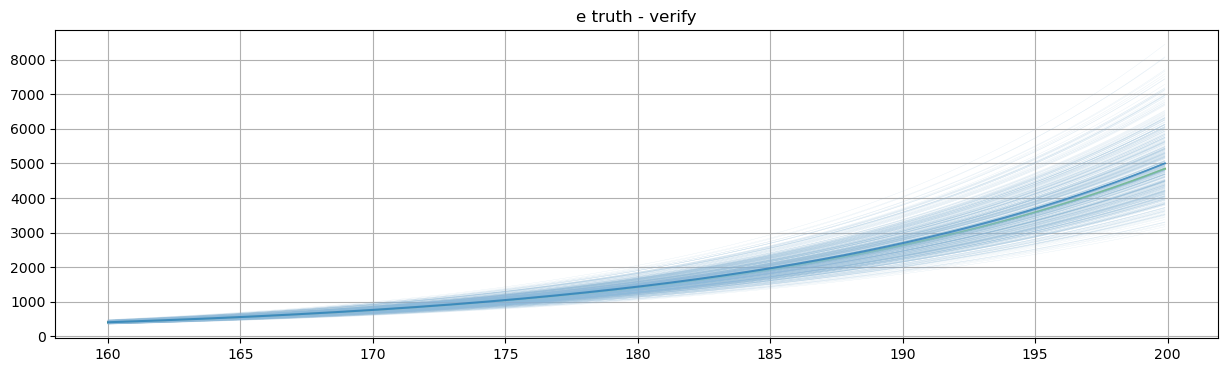

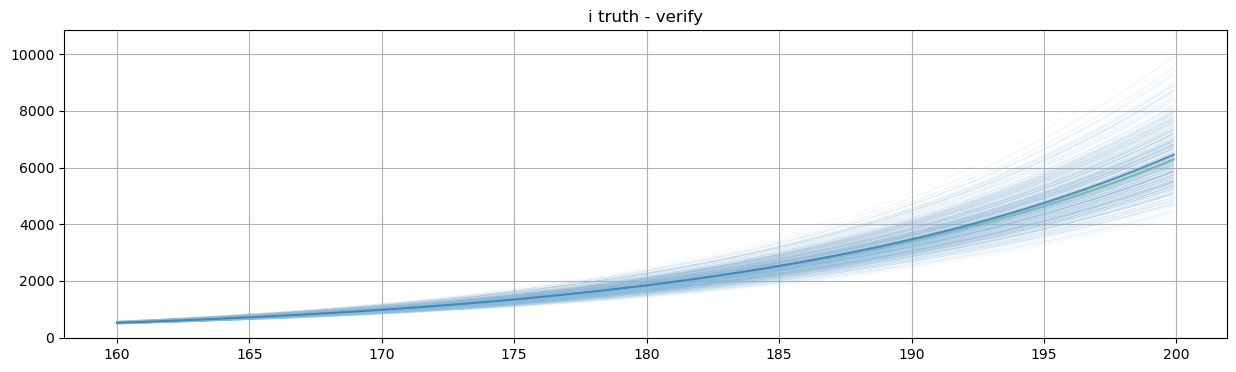

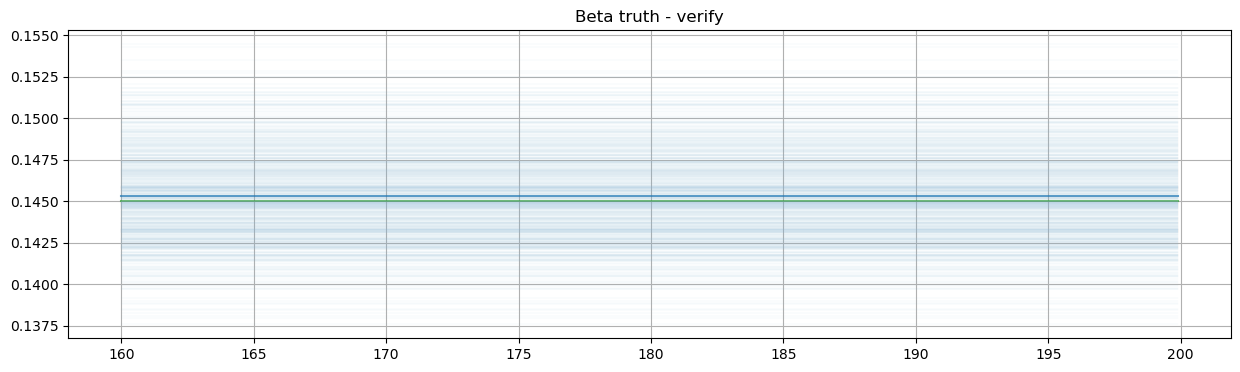

In [36]:
#### Error distributions for Ensemble

### Sudhi DATA #####


# all_truth - column 0: S, column 1: E, column 2: I, column 3: R, column 4: D
# beta_truth - beta values corresponding to all_truth time steps


population = 1          # Update if E and I are in fractions of population
synthetic_truth = all_truth.T   # Update if different
t = np.copy(tmoh[1600:])         # Update if different 
t_start_index = 1600                        # Update if different 

e_error,i_error,beta_error = np.zeros(len(t)), np.zeros(len(t)), np.zeros(len(t))
e_var,i_var,beta_var = np.zeros(len(t)), np.zeros(len(t)), np.zeros(len(t))

e_rel_error,i_rel_error,beta_rel_error = np.zeros(len(t)), np.zeros(len(t)), np.zeros(len(t))
e_rel_var,i_rel_var,beta_rel_var = np.zeros(len(t)), np.zeros(len(t)), np.zeros(len(t))

e_mu,i_mu,b_mu = np.zeros(len(t)), np.zeros(len(t)), np.zeros(len(t))
e_sigma,i_sigma,b_sigma = np.zeros(len(t)), np.zeros(len(t)), np.zeros(len(t))

e_ensemble = np.copy(e_append[t_start_index::].T)            # Update 
i_ensemble = np.copy(i_append[t_start_index::].T)            # Update 
b_ensemble = np.copy(beta_append[t_start_index::].T)            # Update 

e_truth = np.copy(synthetic_truth[1,t_start_index::])            # Update 
i_truth = np.copy(synthetic_truth[2,t_start_index::])            # Update 
b_truth = np.copy(beta_truth[t_start_index:])     


for ii in range(len(t)):

    e_mu[ii] = np.mean(e_ensemble[:,ii])
    i_mu[ii] = np.mean(i_ensemble[:,ii])
    b_mu[ii] = np.mean(b_ensemble[:,ii])

    e_sigma[ii] = np.var(e_ensemble[:,ii])
    i_sigma[ii] = np.var(i_ensemble[:,ii])
    b_sigma[ii] = np.var(b_ensemble[:,ii])

    e_error[ii] = population*(e_mu[ii] - e_truth[ii])
    i_error[ii] = population*(i_mu[ii] - i_truth[ii])
    beta_error[ii] = b_mu[ii] - b_truth[ii]

    e_var[ii] = population**2*e_sigma[ii]
    i_var[ii] = population**2*i_sigma[ii]
    beta_var[ii] = b_sigma[ii]

    e_rel_error[ii] = (e_mu[ii] - e_truth[ii])/e_truth[ii]
    i_rel_error[ii] = (i_mu[ii] - i_truth[ii])/i_truth[ii]
    beta_rel_error[ii] = (b_mu[ii] - b_truth[ii])/b_truth[ii]

    e_rel_var[ii] = e_sigma[ii]/e_truth[ii]**2
    i_rel_var[ii] = i_sigma[ii]/i_truth[ii]**2
    beta_rel_var[ii] = b_sigma[ii]/b_truth[ii]**2

e_ese = e_error**2 + e_var
i_ese = i_error**2 + i_var
beta_ese = beta_error**2 + beta_var


e_rel_ese = e_rel_error**2 + e_rel_var
i_rel_ese = i_rel_error**2 + i_rel_var
beta_rel_ese = beta_rel_error**2 + beta_rel_var




plt.figure(figsize=(15,4))
plt.title('e truth - verify')
plt.grid()
# plt.plot(t,e_error,alpha=0.7, color='tab:blue')
# plt.plot(t,i_error,alpha=0.7, color='tab:orange')
plt.plot(t,e_truth,alpha=0.7, color='tab:green')
plt.plot(t,e_ensemble[:,:].T,alpha=0.3, color=(142/255,186/255,217/255,0.5), linewidth=0.2, label='_nolegend_')
plt.plot(t,e_mu,alpha=0.7)


plt.figure(figsize=(15,4))
plt.title('i truth - verify')
plt.grid()
# plt.plot(t,e_error,alpha=0.7, color='tab:blue')
# plt.plot(t,i_error,alpha=0.7, color='tab:orange')
plt.plot(t,i_truth,alpha=0.7, color='tab:green')
plt.plot(t,i_ensemble[:,:].T,alpha=0.3, color=(142/255,186/255,217/255,0.5), linewidth=0.2, label='_nolegend_')
plt.plot(t,i_mu,alpha=0.7)

plt.figure(figsize=(15,4))
plt.title('Beta truth - verify')
plt.grid()
# plt.plot(t,e_error,alpha=0.7, color='tab:blue')
# plt.plot(t,i_error,alpha=0.7, color='tab:orange')
plt.plot(t,b_truth,alpha=0.7, color='tab:green')
plt.plot(t,b_ensemble[:,:].T,alpha=0.3, color=(142/255,186/255,217/255,0.5), linewidth=0.2, label='_nolegend_')
plt.plot(t,b_mu,alpha=0.7)

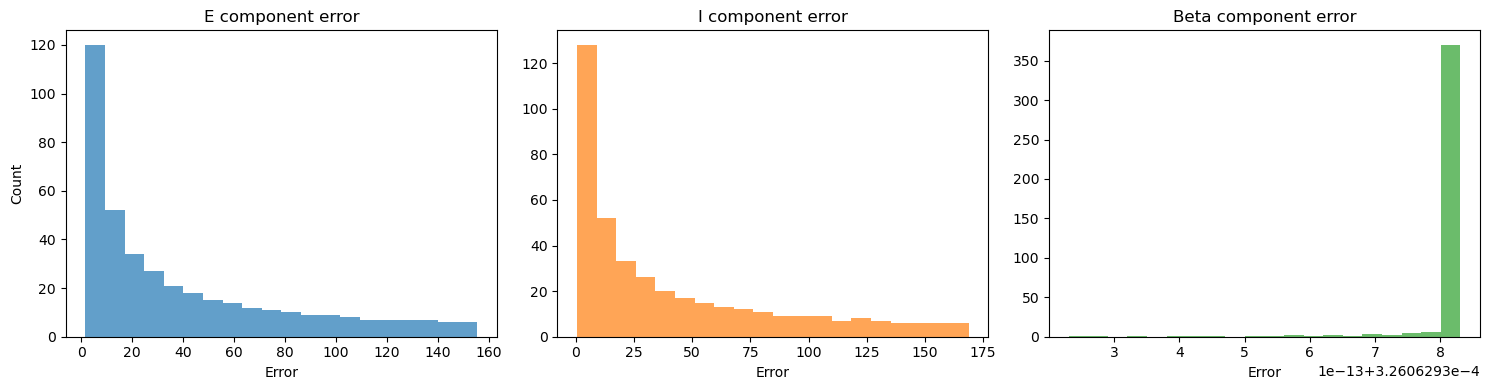

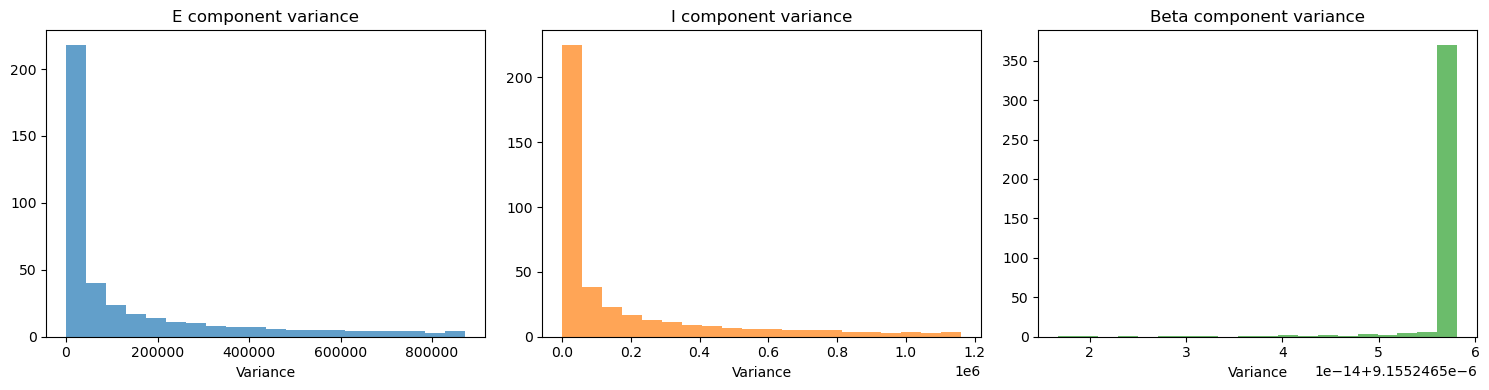

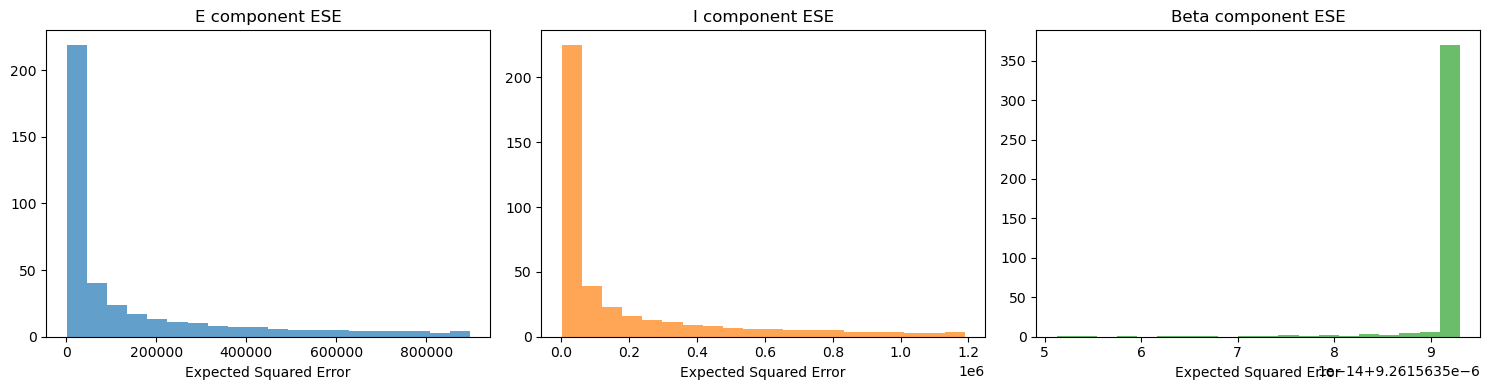

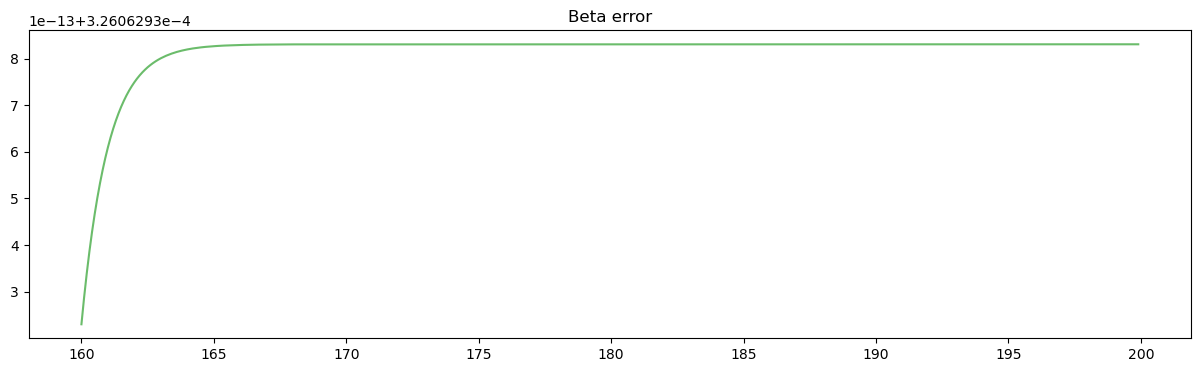

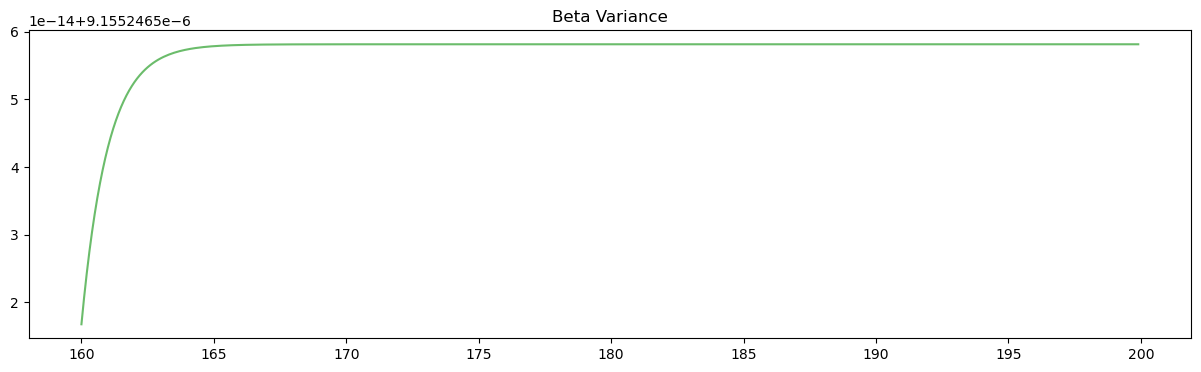

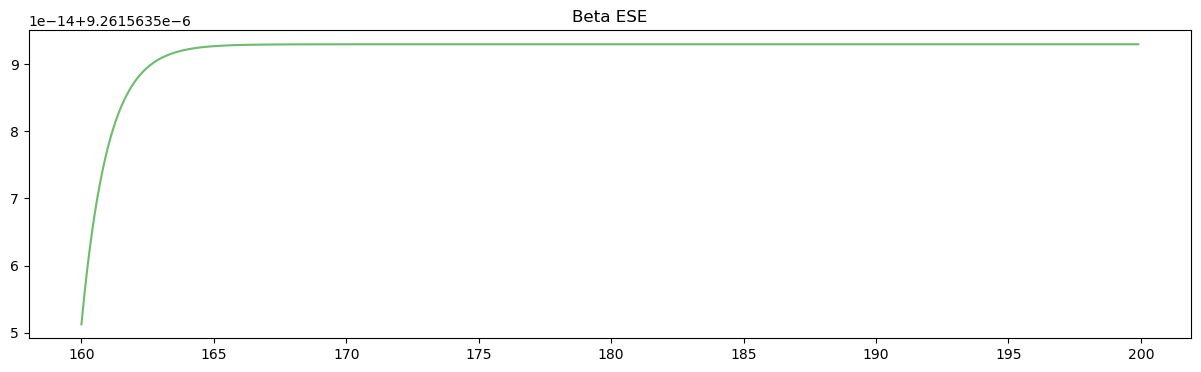

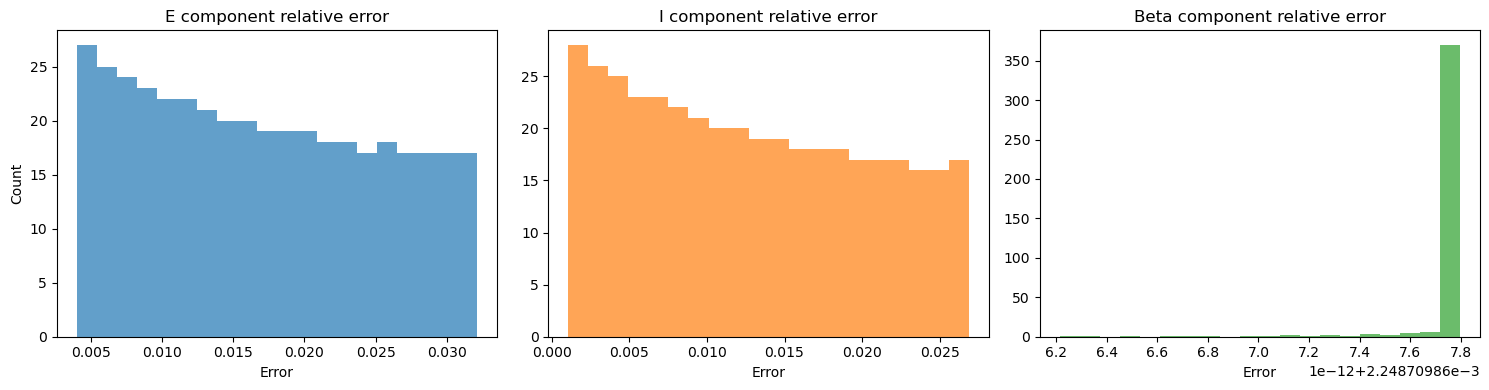

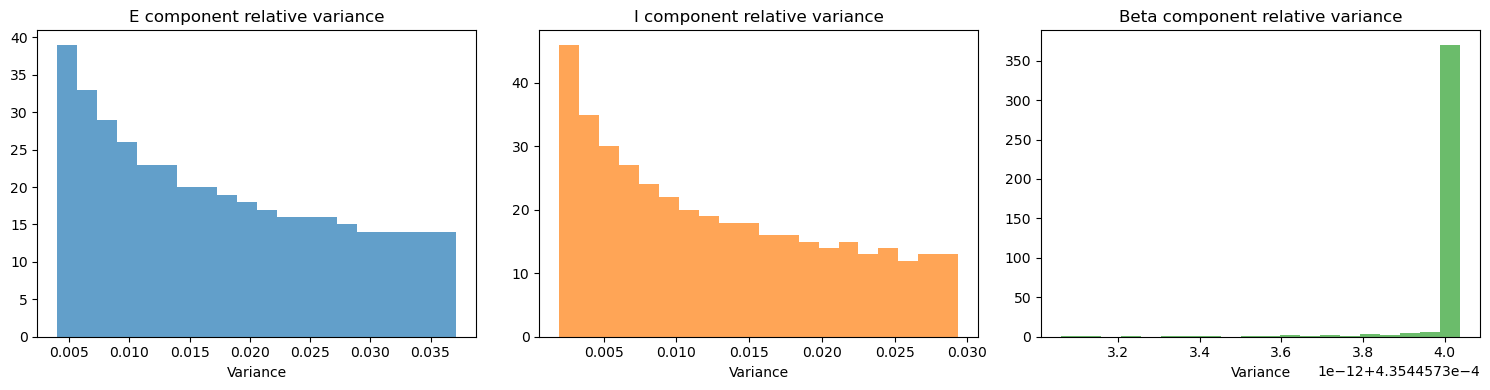

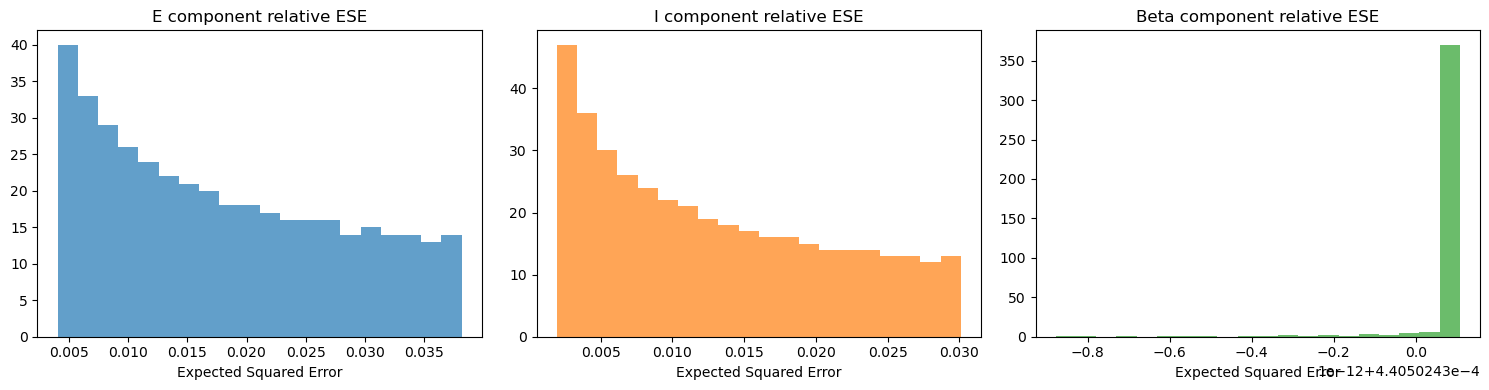

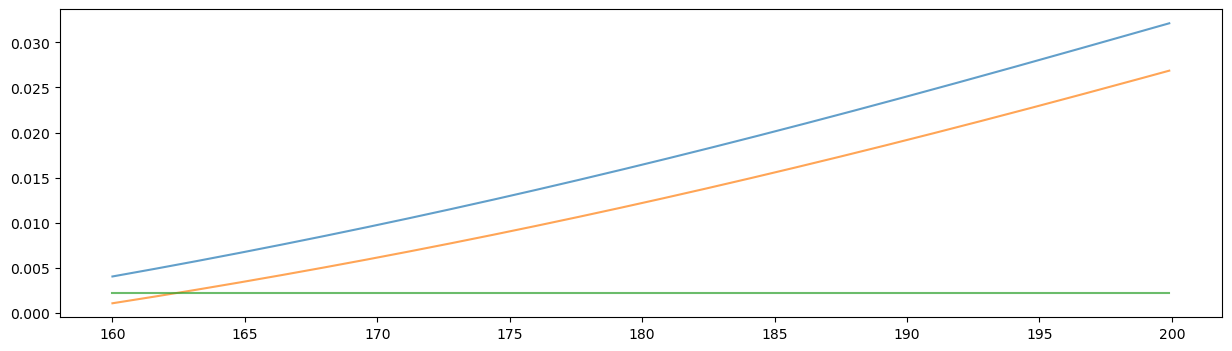

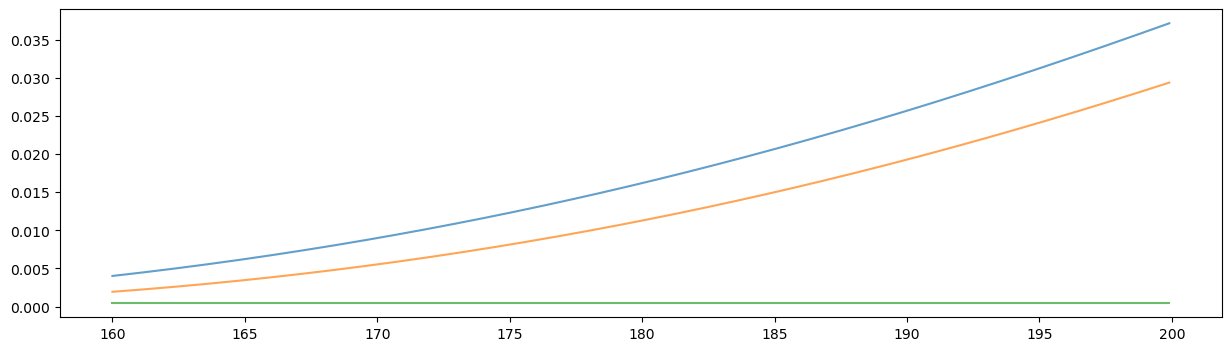

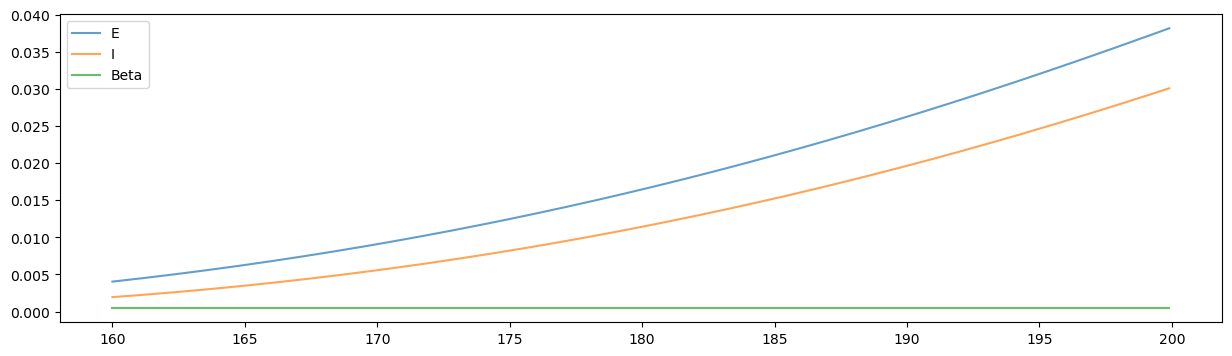

In [37]:
### PLOT MEAN, VARIANCE and EXPECTED SQUARE ERROR of ERRORS

## MEAN

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.hist(e_error, bins=20, alpha=0.7, color='tab:blue')
plt.title('E component error')
plt.xlabel('Error'); plt.ylabel('Count')

plt.subplot(1,3,2)
plt.hist(i_error, bins=20, alpha=0.7, color='tab:orange')
plt.title('I component error')
plt.xlabel('Error')

plt.subplot(1,3,3)
plt.hist(beta_error, bins=20, alpha=0.7, color='tab:green')
plt.title('Beta component error')
plt.xlabel('Error')

plt.tight_layout()
plt.show()

## VAR

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.hist(e_var, bins=20, alpha=0.7, color='tab:blue')
plt.title('E component variance')
plt.xlabel('Variance')

plt.subplot(1,3,2)
plt.hist(i_var, bins=20, alpha=0.7, color='tab:orange')
plt.title('I component variance')
plt.xlabel('Variance')

plt.subplot(1,3,3)
plt.hist(beta_var, bins=20, alpha=0.7, color='tab:green')
plt.title('Beta component variance')
plt.xlabel('Variance')

plt.tight_layout()
plt.show()

## ESE

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.hist(e_ese, bins=20, alpha=0.7, color='tab:blue')
plt.title('E component ESE')
plt.xlabel('Expected Squared Error')

plt.subplot(1,3,2)
plt.hist(i_ese, bins=20, alpha=0.7, color='tab:orange')
plt.title('I component ESE')
plt.xlabel('Expected Squared Error')

plt.subplot(1,3,3)
plt.hist(beta_ese, bins=20, alpha=0.7, color='tab:green')
plt.title('Beta component ESE')
plt.xlabel('Expected Squared Error')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15,4))
plt.title('Beta error')
# plt.plot(t,e_error,alpha=0.7, color='tab:blue')
# plt.plot(t,i_error,alpha=0.7, color='tab:orange')
plt.plot(t,beta_error,alpha=0.7, color='tab:green')


# plt.subplot(3,1,2)
plt.figure(figsize=(15,4))
plt.title('Beta Variance')
# plt.plot(t,e_var,alpha=0.7, color='tab:blue')
# plt.plot(t,i_var,alpha=0.7, color='tab:orange')
plt.plot(t,beta_var,alpha=0.7, color='tab:green')


# plt.subplot(3,1,3)
plt.figure(figsize=(15,4))
# plt.plot(t,e_ese,alpha=0.7, color='tab:blue')
# plt.plot(t,i_ese,alpha=0.7, color='tab:orange')
plt.title('Beta ESE')
plt.plot(t,beta_ese,alpha=0.7, color='tab:green')



### PLOT MEAN, VARIANCE and EXPECTED SQUARE ERROR of ERRORS

## MEAN

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.hist(e_rel_error, bins=20, alpha=0.7, color='tab:blue')
plt.title('E component relative error')
plt.xlabel('Error'); plt.ylabel('Count')

plt.subplot(1,3,2)
plt.hist(i_rel_error, bins=20, alpha=0.7, color='tab:orange')
plt.title('I component relative error')
plt.xlabel('Error')

plt.subplot(1,3,3)
plt.hist(beta_rel_error, bins=20, alpha=0.7, color='tab:green')
plt.title('Beta component relative error')
plt.xlabel('Error')

plt.tight_layout()
plt.show()

## VAR

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.hist(e_rel_var, bins=20, alpha=0.7, color='tab:blue')
plt.title('E component relative variance')
plt.xlabel('Variance')

plt.subplot(1,3,2)
plt.hist(i_rel_var, bins=20, alpha=0.7, color='tab:orange')
plt.title('I component relative variance')
plt.xlabel('Variance')

plt.subplot(1,3,3)
plt.hist(beta_rel_var, bins=20, alpha=0.7, color='tab:green')
plt.title('Beta component relative variance')
plt.xlabel('Variance')

plt.tight_layout()
plt.show()

## ESE

plt.figure(figsize=(15,4))
plt.subplot(1,3,1)
plt.hist(e_rel_ese, bins=20, alpha=0.7, color='tab:blue')
plt.title('E component relative ESE')
plt.xlabel('Expected Squared Error')

plt.subplot(1,3,2)
plt.hist(i_rel_ese, bins=20, alpha=0.7, color='tab:orange')
plt.title('I component relative ESE')
plt.xlabel('Expected Squared Error')

plt.subplot(1,3,3)
plt.hist(beta_rel_ese, bins=20, alpha=0.7, color='tab:green')
plt.title('Beta component relative ESE')
plt.xlabel('Expected Squared Error')

plt.tight_layout()
plt.show()



plt.figure(figsize=(15,4))
plt.plot(t,e_rel_error,alpha=0.7, color='tab:blue')
plt.plot(t,i_rel_error,alpha=0.7, color='tab:orange')
plt.plot(t,beta_rel_error,alpha=0.7, color='tab:green')


# plt.subplot(3,1,2)
plt.figure(figsize=(15,4))
plt.plot(t,e_rel_var,alpha=0.7, color='tab:blue')
plt.plot(t,i_rel_var,alpha=0.7, color='tab:orange')
plt.plot(t,beta_rel_var,alpha=0.7, color='tab:green')


# plt.subplot(3,1,3)
plt.figure(figsize=(15,4))
plt.plot(t,e_rel_ese,alpha=0.7, color='tab:blue')
plt.plot(t,i_rel_ese,alpha=0.7, color='tab:orange')
plt.plot(t,beta_rel_ese,alpha=0.7, color='tab:green')
plt.legend(['E','I','Beta'])

